# Per-Drone DL Orientation Sweep Analysis

## Research Question

Can we improve each heuristic method by optimizing the DL antenna orientation
(tilt + azimuth) of each drone independently?

For each heuristic deployment:
1. Keep drone positions fixed (from the heuristic)
2. Sweep each drone's DL tilt [0, 60 deg] and azimuth [0, 355 deg]
3. Find per-drone best orientation (coordinate-wise optimization)
4. Apply all per-drone best orientations and evaluate the joint result

**Key insight:** BH interference depends only on BH antenna orientations and
positions (not DL), so only DL coverage/SINR change in the sweep.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

# ── Configuration ─────────────────────────────────────────────────────
RUN_ID = "46540284"  # SLURM array job ID

ZETA = 0.7  # Coverage weight in combined score
# ─────────────────────────────────────────────────────────────────────

if RUN_ID.isdigit():
    RESULTS_DIR = Path('../results/angle_sweep') / f'run_{RUN_ID}'
else:
    RESULTS_DIR = Path('../results/angle_sweep') / RUN_ID

# Try single-file fallback for quick test
SINGLE_FILE = Path('../results/angle_sweep_results.json')
QUICK_FILE = Path('../results/angle_sweep_quick.json')

INTERF_BEST_DBM  = -70.0
INTERF_WORST_DBM = -30.0

def compute_combined_score(coverage_pct, total_interference_dbm, zeta=ZETA):
    cov_01 = coverage_pct / 100.0
    interf_01 = np.clip(
        (INTERF_WORST_DBM - total_interference_dbm) / (INTERF_WORST_DBM - INTERF_BEST_DBM),
        0.0, 1.0,
    )
    return zeta * cov_01 + (1.0 - zeta) * interf_01

# ── Load results ──────────────────────────────────────────────────────
files = []
if RESULTS_DIR.exists():
    files = sorted(RESULTS_DIR.glob('task_*.json'))
    print(f'Run ID:     {RUN_ID}')
    print(f'Result dir: {RESULTS_DIR}')
    print(f'Found {len(files)} task files')
elif SINGLE_FILE.exists():
    files = [SINGLE_FILE]
    print(f'Single file: {SINGLE_FILE}')
elif QUICK_FILE.exists():
    files = [QUICK_FILE]
    print(f'Quick file: {QUICK_FILE}')
else:
    raise FileNotFoundError(
        f'No results found. Checked: {RESULTS_DIR}, {SINGLE_FILE}, {QUICK_FILE}'
    )

# Parse all task files
all_data = []
for f in files:
    all_data.append(json.loads(f.read_text()))

# Extract available methods from first file
_ALL_METHODS = ['kmeans', 'analytic', 'analytic_pca', 'repulsive_lloyd', 'altitude_stagger']
_available = set(all_data[0]['results'].keys())
METHODS = [m for m in _ALL_METHODS if m in _available]

METHOD_LABELS = {
    'kmeans':           'K-means',
    'analytic':         'Analytic',
    'analytic_pca':     'Analytic+PCA',
    'repulsive_lloyd':  'Repulsive Lloyd',
    'altitude_stagger': 'Alt. Stagger',
}

COLORS = {
    'kmeans':           '#0072B2',
    'analytic':         '#E69F00',
    'analytic_pca':     '#F0E442',
    'repulsive_lloyd':  '#009E73',
    'altitude_stagger': '#D55E00',
}

# Extract sweep grid from config
tilt_angles = np.array(all_data[0]['config']['tilt_angles_deg'])
azimuths = np.array(all_data[0]['config']['azimuths_deg'])
stored_zeta = all_data[0]['config']['zeta']

print(f'Zeta (notebook): {ZETA}  (stored: {stored_zeta})')
print(f'Methods:    {METHODS}')
print(f'Tilt range: {tilt_angles[0]}-{tilt_angles[-1]} deg (n={len(tilt_angles)})')
print(f'Az range:   {azimuths[0]}-{azimuths[-1]} deg (n={len(azimuths)})')

## 1. Summary Table: Baseline vs Optimized

In [22]:
# Build summary dataframe
summary_rows = []
for d in all_data:
    cfg = d['config']
    for m in METHODS:
        if m not in d['results']:
            continue
        r = d['results'][m]
        bl = r['baseline']
        op = r['optimized']
        # Recompute combined score with notebook ZETA
        bl_score = compute_combined_score(bl['coverage_pct'], bl['total_interference_dbm'])
        op_score = compute_combined_score(op['coverage_pct'], op['total_interference_dbm'])
        summary_rows.append({
            'n_drones': cfg['n_drones'],
            'target_users': cfg['target_users'],
            'distribution': cfg['distribution'],
            'method': m,
            'baseline_cov': bl['coverage_pct'],
            'optimized_cov': op['coverage_pct'],
            'delta_cov': op['coverage_pct'] - bl['coverage_pct'],
            'baseline_score': bl_score,
            'optimized_score': op_score,
            'delta_score': op_score - bl_score,
            'baseline_interf': bl['total_interference_dbm'],
            'optimized_interf': op['total_interference_dbm'],
            'baseline_sinr': bl['mean_sinr_db'],
            'optimized_sinr': op['mean_sinr_db'],
        })

df = pd.DataFrame(summary_rows)

# Print summary
print(f"{'Drones':>6}  {'Users':>6}  {'Dist':<10}  {'Method':<16}  "
      f"{'Base Cov':>8}  {'Opt Cov':>8}  {'Delta':>7}  "
      f"{'Base Score':>10}  {'Opt Score':>10}")
print('\u2500' * 100)
for _, r in df.iterrows():
    print(f"{int(r['n_drones']):>6}  {int(r['target_users']):>6}  {r['distribution']:<10}  "
          f"{METHOD_LABELS.get(r['method'], r['method']):<16}  "
          f"{r['baseline_cov']:7.1f}%  {r['optimized_cov']:7.1f}%  {r['delta_cov']:+6.1f}  "
          f"{r['baseline_score']:10.4f}  {r['optimized_score']:10.4f}")

Drones   Users  Dist        Method            Base Cov   Opt Cov    Delta  Base Score   Opt Score
────────────────────────────────────────────────────────────────────────────────────────────────────
     5     100  clustered   K-means              97.1%     98.5%    +1.5      0.8231      0.8334
     5     100  clustered   Analytic             97.5%     98.1%    +0.6      0.8339      0.8381


## 2. Improvement Bar Chart

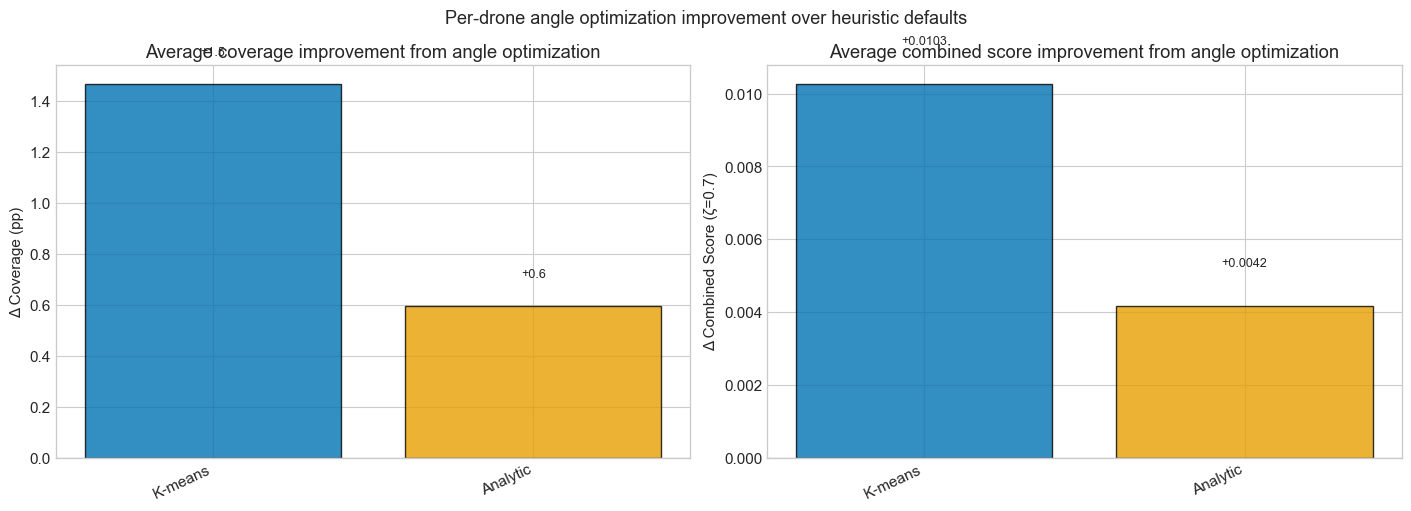

In [23]:
# Average improvement per method across all configurations
avg_improvement = df.groupby('method')[['delta_cov', 'delta_score']].mean()
avg_improvement = avg_improvement.reindex(METHODS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

labels = [METHOD_LABELS.get(m, m) for m in avg_improvement.index]
colors = [COLORS.get(m, '#999') for m in avg_improvement.index]
x = np.arange(len(labels))

# Coverage improvement
bars = axes[0].bar(x, avg_improvement['delta_cov'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('\u0394 Coverage (pp)')
axes[0].set_title('Average coverage improvement from angle optimization')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha='right')
axes[0].axhline(0, color='grey', linewidth=0.8)
for bar, val in zip(bars, avg_improvement['delta_cov']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:+.1f}', ha='center', va='bottom', fontsize=9)

# Score improvement
bars = axes[1].bar(x, avg_improvement['delta_score'], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel(f'\u0394 Combined Score (\u03b6={ZETA})')
axes[1].set_title('Average combined score improvement from angle optimization')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha='right')
axes[1].axhline(0, color='grey', linewidth=0.8)
for bar, val in zip(bars, avg_improvement['delta_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:+.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Per-drone angle optimization improvement over heuristic defaults', fontsize=13)
plt.show()

## 3. Per-Drone Orientation Heatmaps

For a selected configuration, show the coverage landscape (tilt x azimuth) for each drone.
Markers indicate the heuristic default orientation (circle) and the sweep-best orientation (star).

Showing heatmaps for: N=5 drones, ~100 users, dist=clustered


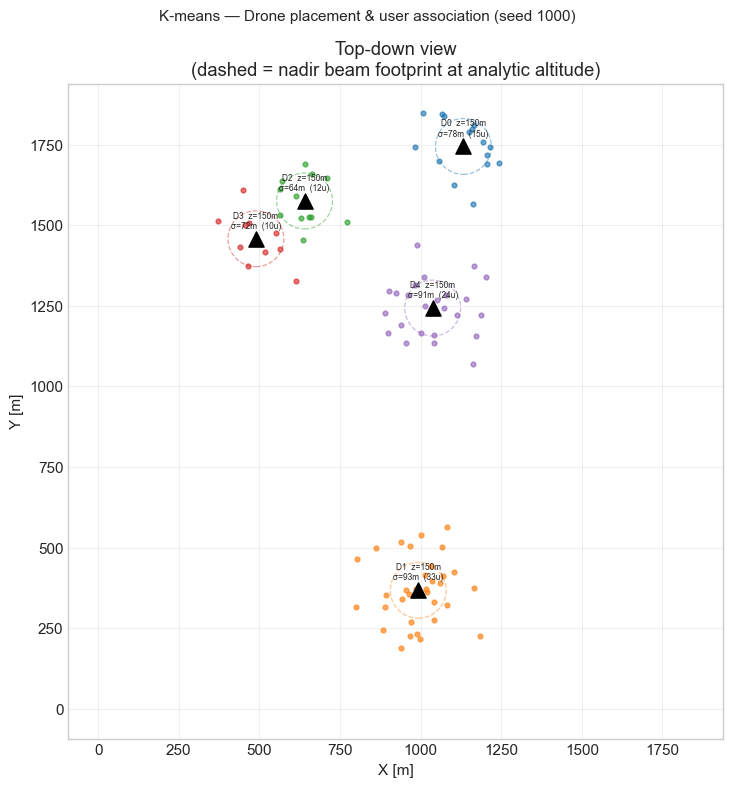

/Users/jbn/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


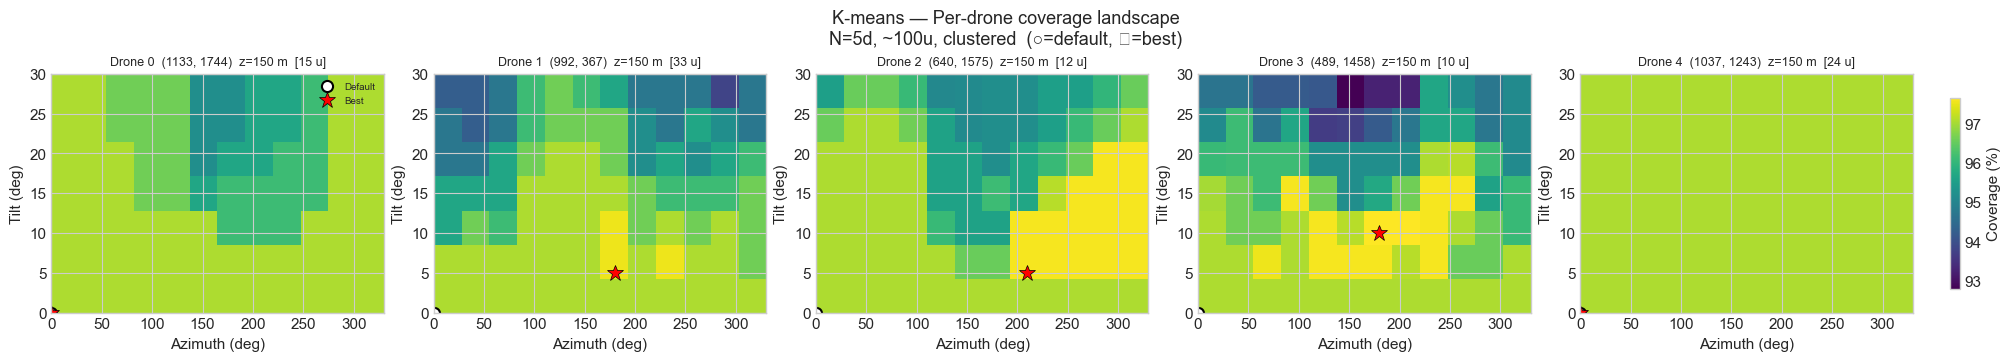

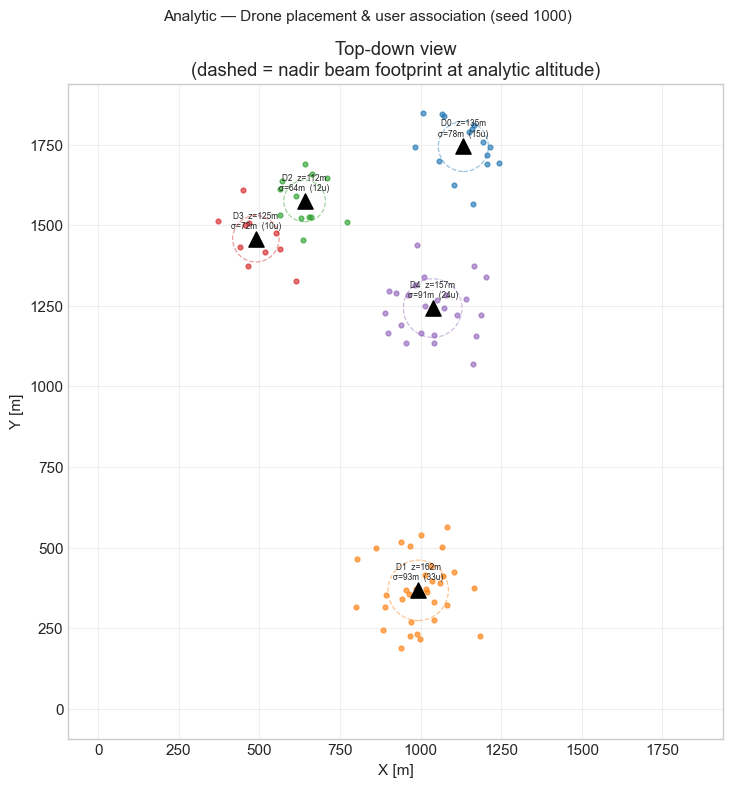

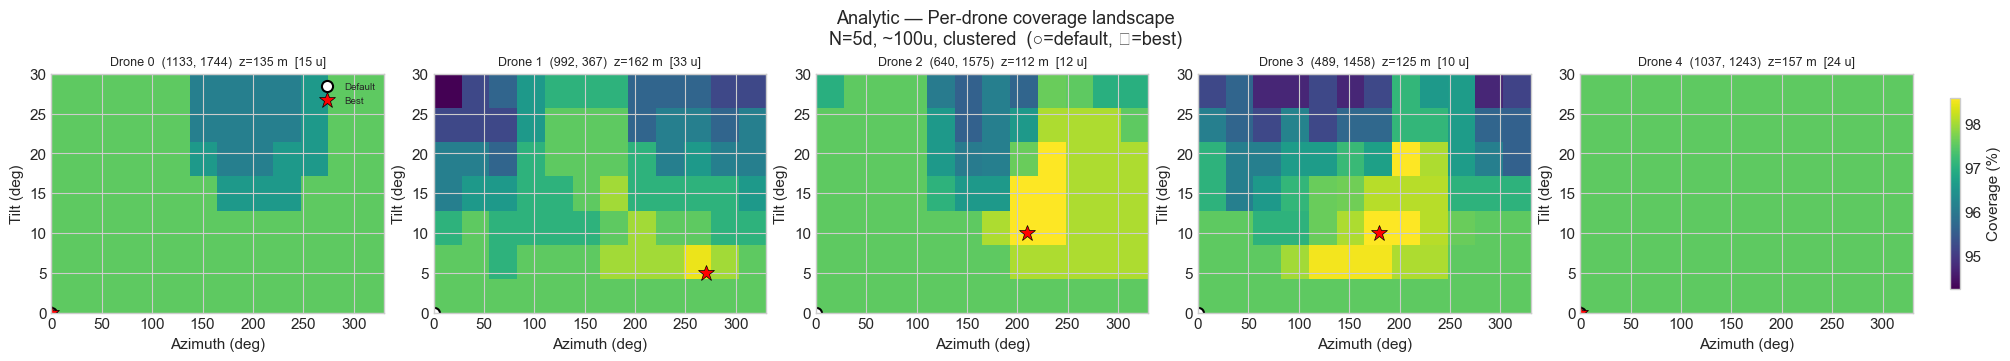

In [24]:
import sys as _sys
_sys.path.insert(0, str(Path('../').resolve()))
_sys.path.insert(0, str(Path('../scripts').resolve()))

from dronecomm.sinr import nearest_drone_association
from dronecomm.visualization import plot_drone_placement_2d
from run_per_drone_angle_sweep import (
    make_config, generate_users_for_distribution, deploy_method,
)

# Select a configuration to visualize
ref_data = all_data[0]
ref_cfg = ref_data['config']
print(f"Showing heatmaps for: N={ref_cfg['n_drones']} drones, "
      f"~{ref_cfg['target_users']} users, dist={ref_cfg['distribution']}")

EVAL_BASE_SEED = 1000  # first seed used by the experiment script

for m in METHODS:
    if m not in ref_data['results']:
        continue
    r = ref_data['results'][m]
    per_drone = r['per_drone']
    n_drones = len(per_drone)

    # ── Re-deploy using reference seed to recover drone / user positions ──
    ref_config = make_config(ref_cfg['n_drones'], ref_cfg['target_users'], ref_cfg['distribution'])
    rng = np.random.default_rng(EVAL_BASE_SEED)
    user_pos = generate_users_for_distribution(
        ref_cfg['distribution'], ref_cfg['target_users'], ref_config, rng,
    )
    scenario = deploy_method(m, ref_config, user_pos, seed=EVAL_BASE_SEED)
    association = nearest_drone_association(scenario.drone_positions, user_pos)

    # ── Spatial layout: drone positions + user association ────────────────
    fig_layout = plot_drone_placement_2d(
        scenario.drone_positions, user_pos, association,
        title=f"{METHOD_LABELS.get(m, m)} — Drone placement & user association "
              f"(seed {EVAL_BASE_SEED})",
    )
    plt.show()

    # ── Per-drone coverage heatmaps (tilt × azimuth) ──────────────────────
    if 'coverage_grid' not in per_drone[0]:
        print(f'  {METHOD_LABELS.get(m, m)}: no grids stored (use --save-grids)')
        continue

    ncols = min(5, n_drones)
    nrows = (n_drones + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                             constrained_layout=True)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    # Shared colour scale across all drones for this method
    all_grids = [np.array(pd['coverage_grid']) for pd in per_drone]
    vmin = min(g.min() for g in all_grids)
    vmax = max(g.max() for g in all_grids)

    for j, pd in enumerate(per_drone):
        row, col = divmod(j, ncols)
        ax = axes[row, col]
        grid = np.array(pd['coverage_grid'])

        im = ax.imshow(grid, aspect='auto', cmap='viridis', origin='lower',
                       vmin=vmin, vmax=vmax,
                       extent=[azimuths[0], azimuths[-1], tilt_angles[0], tilt_angles[-1]])

        # Mark default orientation
        def_t = pd['avg_default_tilt_deg']
        def_a = pd['avg_default_azimuth_deg']
        ax.plot(def_a, def_t, 'wo', markersize=8, markeredgecolor='black',
                markeredgewidth=1.5, label='Default')

        # Mark best orientation
        best_t = pd['best_tilt_deg']
        best_a = pd['best_azimuth_deg']
        ax.plot(best_a, best_t, 'r*', markersize=12, markeredgecolor='black',
                markeredgewidth=0.5, label='Best')

        ax.set_xlabel('Azimuth (deg)')
        ax.set_ylabel('Tilt (deg)')

        # Title includes drone XY and altitude so the heatmap can be
        # cross-referenced with the spatial layout above
        dpos = scenario.drone_positions[j]
        n_users_served = int((association == j).sum())
        ax.set_title(
            f'Drone {j}  ({dpos[0]:.0f}, {dpos[1]:.0f})  z={dpos[2]:.0f} m  '
            f'[{n_users_served} u]',
            fontsize=9,
        )
        if j == 0:
            ax.legend(fontsize=7, loc='upper right')

    # Hide unused subplots
    for j in range(n_drones, nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row, col].set_visible(False)

    fig.colorbar(im, ax=axes.ravel().tolist(), label='Coverage (%)', shrink=0.8, pad=0.02)
    fig.suptitle(
        f'{METHOD_LABELS.get(m, m)} — Per-drone coverage landscape\n'
        f'N={ref_cfg["n_drones"]}d, ~{ref_cfg["target_users"]}u, '
        f'{ref_cfg["distribution"]}  (○=default, ★=best)',
        fontsize=13,
    )
    plt.show()

## 4. Default vs Optimal Orientation Comparison

Arrow plot showing how each drone's orientation shifts from the heuristic default to the sweep-optimal.

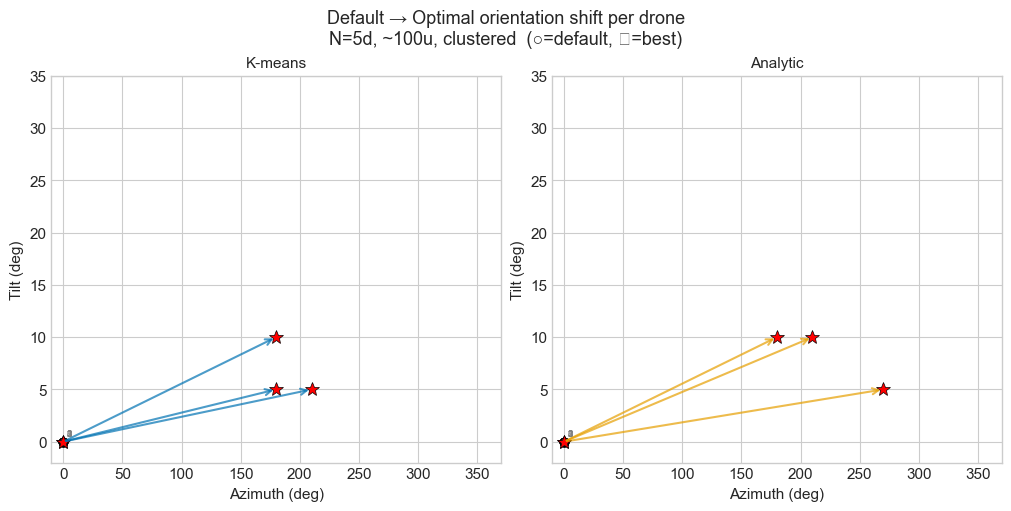

In [25]:
ref_data = all_data[0]
ref_cfg = ref_data['config']

n_methods = len([m for m in METHODS if m in ref_data['results']])
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5), constrained_layout=True)
if n_methods == 1:
    axes = [axes]

for ax, m in zip(axes, METHODS):
    if m not in ref_data['results']:
        ax.set_visible(False)
        continue
    per_drone = ref_data['results'][m]['per_drone']
    for j, pd in enumerate(per_drone):
        def_t = pd['avg_default_tilt_deg']
        def_a = pd['avg_default_azimuth_deg']
        best_t = pd['best_tilt_deg']
        best_a = pd['best_azimuth_deg']
        ax.annotate('', xy=(best_a, best_t), xytext=(def_a, def_t),
                     arrowprops=dict(arrowstyle='->', color=COLORS.get(m, '#999'),
                                     lw=1.5, alpha=0.7))
        ax.plot(def_a, def_t, 'o', color='white', markersize=6,
                markeredgecolor='black', markeredgewidth=1)
        ax.plot(best_a, best_t, '*', color='red', markersize=10,
                markeredgecolor='black', markeredgewidth=0.5)
        ax.text(def_a + 3, def_t + 0.5, str(j), fontsize=7, color='grey')

    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Tilt (deg)')
    ax.set_title(METHOD_LABELS.get(m, m), fontsize=11)
    ax.set_xlim(-10, 370)
    ax.set_ylim(-2, tilt_angles[-1] + 5)

fig.suptitle(f'Default \u2192 Optimal orientation shift per drone\n'
             f'N={ref_cfg["n_drones"]}d, ~{ref_cfg["target_users"]}u, '
             f'{ref_cfg["distribution"]}  (\u25CB=default, \u2605=best)',
             fontsize=13)
plt.show()

## 5. Per-Seed Distributions (Boxplots)

Compare per-seed baseline vs optimized coverage and combined score.

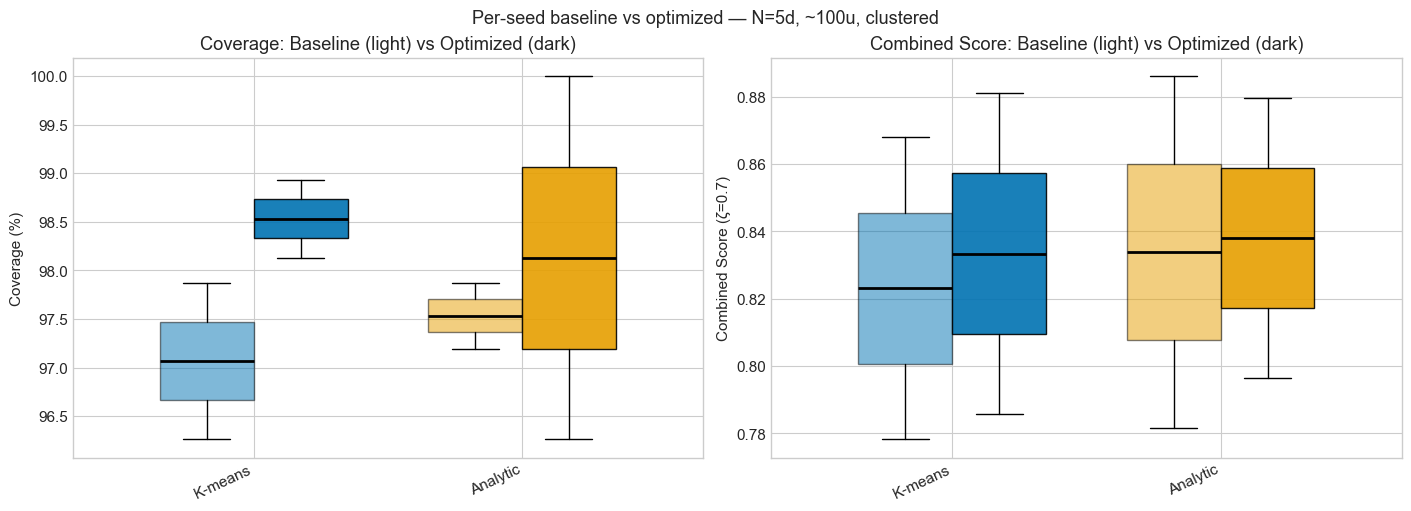

In [26]:
ref_data = all_data[0]
ref_cfg = ref_data['config']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Coverage boxplots: baseline vs optimized per method
bp_data_bl = []
bp_data_op = []
bp_labels = []
bp_colors = []

for m in METHODS:
    if m not in ref_data['results']:
        continue
    r = ref_data['results'][m]
    bl_covs = [s['coverage_pct'] for s in r['baseline_per_seed']]
    op_covs = [s['coverage_pct'] for s in r['optimized_per_seed']]
    bp_data_bl.append(bl_covs)
    bp_data_op.append(op_covs)
    bp_labels.append(METHOD_LABELS.get(m, m))
    bp_colors.append(COLORS.get(m, '#999'))

n_m = len(bp_labels)
x = np.arange(n_m)
width = 0.35

bp1 = axes[0].boxplot(bp_data_bl, positions=x - width/2, widths=width,
                       patch_artist=True)
bp2 = axes[0].boxplot(bp_data_op, positions=x + width/2, widths=width,
                       patch_artist=True)
for patch, color in zip(bp1['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
for patch, color in zip(bp2['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
for element in ['medians']:
    for item in bp1[element] + bp2[element]:
        item.set_color('black')
        item.set_linewidth(2)

axes[0].set_xticks(x)
axes[0].set_xticklabels(bp_labels, rotation=25, ha='right')
axes[0].set_ylabel('Coverage (%)')
axes[0].set_title('Coverage: Baseline (light) vs Optimized (dark)')

# Combined score boxplots
bp_data_bl_s = []
bp_data_op_s = []
for m in METHODS:
    if m not in ref_data['results']:
        continue
    r = ref_data['results'][m]
    bl_scores = [compute_combined_score(s['coverage_pct'], s['total_interference_dbm'])
                 for s in r['baseline_per_seed']]
    op_scores = [compute_combined_score(s['coverage_pct'], s['total_interference_dbm'])
                 for s in r['optimized_per_seed']]
    bp_data_bl_s.append(bl_scores)
    bp_data_op_s.append(op_scores)

bp3 = axes[1].boxplot(bp_data_bl_s, positions=x - width/2, widths=width,
                       patch_artist=True)
bp4 = axes[1].boxplot(bp_data_op_s, positions=x + width/2, widths=width,
                       patch_artist=True)
for patch, color in zip(bp3['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
for patch, color in zip(bp4['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
for element in ['medians']:
    for item in bp3[element] + bp4[element]:
        item.set_color('black')
        item.set_linewidth(2)

axes[1].set_xticks(x)
axes[1].set_xticklabels(bp_labels, rotation=25, ha='right')
axes[1].set_ylabel(f'Combined Score (\u03b6={ZETA})')
axes[1].set_title('Combined Score: Baseline (light) vs Optimized (dark)')

fig.suptitle(f'Per-seed baseline vs optimized — '
             f'N={ref_cfg["n_drones"]}d, ~{ref_cfg["target_users"]}u, '
             f'{ref_cfg["distribution"]}', fontsize=13)
plt.show()

## 6. Improvement Heatmaps (drones x users)

If multiple configurations were run, show improvement from angle optimization
as a function of drone count and user count.

In [27]:
if len(df) > len(METHODS):  # multiple configs
    distributions = sorted(df['distribution'].unique())
    for dist in distributions:
        sub = df[df['distribution'] == dist]
        avail_methods = [m for m in METHODS if m in sub['method'].values]
        n_m = len(avail_methods)
        fig, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 4.5), constrained_layout=True)
        if n_m == 1:
            axes = [axes]

        for ax, m in zip(axes, avail_methods):
            msub = sub[sub['method'] == m]
            if len(msub) < 2:
                ax.set_visible(False)
                continue
            pivot = msub.pivot(index='n_drones', columns='target_users', values='delta_cov')
            abs_max = max(abs(pivot.values.min()), abs(pivot.values.max()), 0.1)
            im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu',
                           vmin=-abs_max, vmax=abs_max, origin='lower')
            ax.set_xticks(range(pivot.shape[1]))
            ax.set_yticks(range(pivot.shape[0]))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel('Target users')
            ax.set_ylabel('N drones')
            ax.set_title(METHOD_LABELS.get(m, m), fontsize=11)
            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    val = pivot.values[i, j]
                    ax.text(j, i, f'{val:+.1f}', ha='center', va='center',
                            fontsize=7, color='black' if abs(val) < abs_max * 0.5 else 'white')

        fig.colorbar(im, ax=list(axes), label='\u0394 Coverage (pp) — blue = improved',
                     shrink=0.8, pad=0.02)
        fig.suptitle(f'Coverage improvement from per-drone angle optimization — {dist}',
                     fontsize=13)
        plt.show()
else:
    print('Only one configuration loaded — skipping improvement heatmaps.')
    print('Run the full sweep grid and reload to see heatmaps.')

Only one configuration loaded — skipping improvement heatmaps.
Run the full sweep grid and reload to see heatmaps.


## 7. Best Angle Distributions

Distribution of per-drone best tilt and azimuth angles across all drones and configurations.

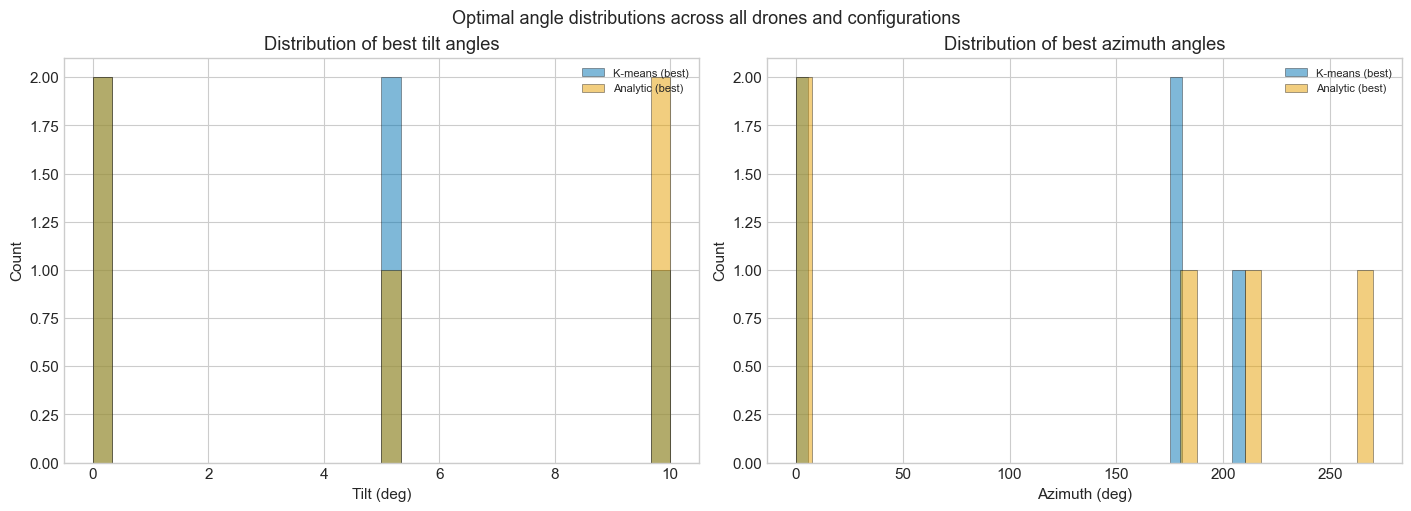

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for m in METHODS:
    best_tilts = []
    best_azimuths = []
    default_tilts = []
    default_azimuths = []
    for d in all_data:
        if m not in d['results']:
            continue
        for pd in d['results'][m]['per_drone']:
            best_tilts.append(pd['best_tilt_deg'])
            best_azimuths.append(pd['best_azimuth_deg'])
            default_tilts.append(pd['avg_default_tilt_deg'])
            default_azimuths.append(pd['avg_default_azimuth_deg'])

    if not best_tilts:
        continue
    color = COLORS.get(m, '#999')
    label = METHOD_LABELS.get(m, m)
    axes[0].hist(best_tilts, bins=30, alpha=0.5, color=color, label=f'{label} (best)',
                 edgecolor='black', linewidth=0.5)
    axes[1].hist(best_azimuths, bins=36, alpha=0.5, color=color, label=f'{label} (best)',
                 edgecolor='black', linewidth=0.5)

axes[0].set_xlabel('Tilt (deg)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of best tilt angles')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Azimuth (deg)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of best azimuth angles')
axes[1].legend(fontsize=8)

fig.suptitle('Optimal angle distributions across all drones and configurations', fontsize=13)
plt.show()

## 8. Tilt Sensitivity (1D Slice at Best Azimuth)

For a selected configuration and method, show how coverage varies with tilt
at the best azimuth for each drone.

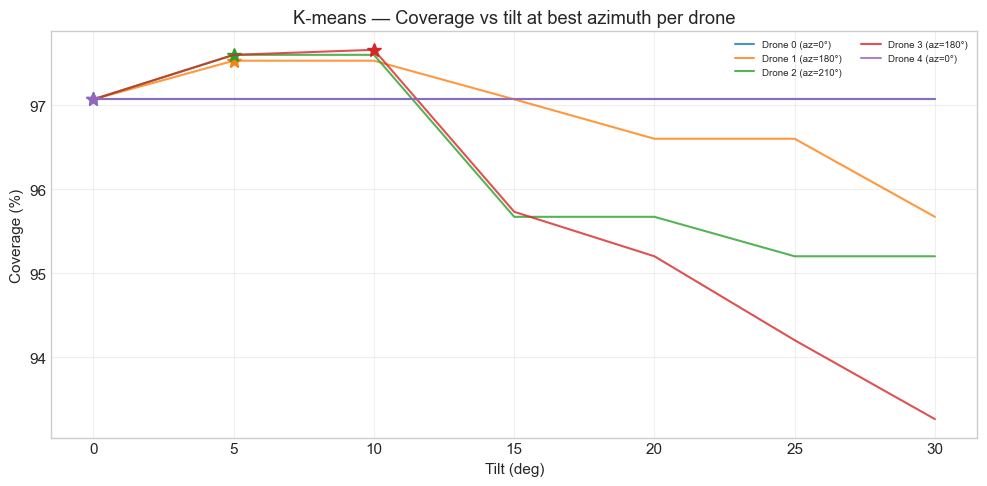

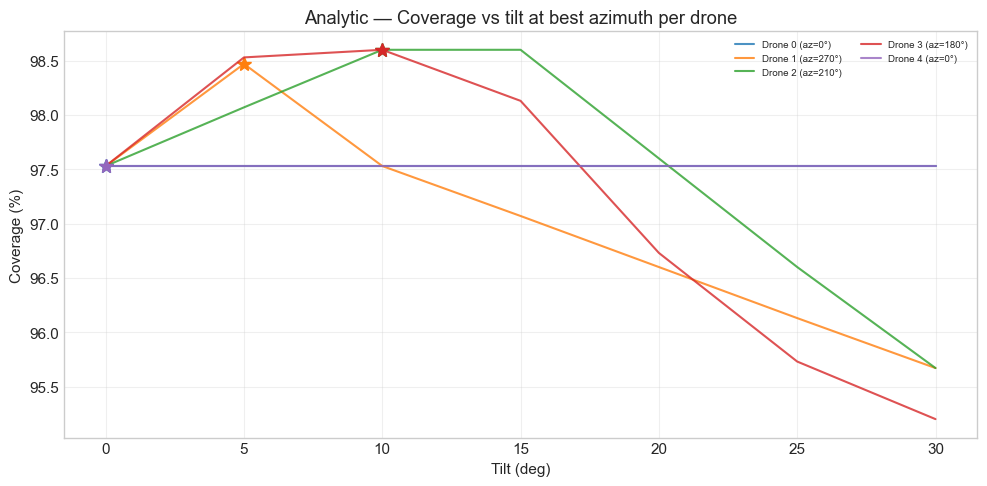

In [29]:
ref_data = all_data[0]
ref_cfg = ref_data['config']

for m in METHODS:
    if m not in ref_data['results']:
        continue
    per_drone = ref_data['results'][m]['per_drone']
    if 'coverage_grid' not in per_drone[0]:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.cm.tab10

    for j, pd in enumerate(per_drone):
        grid = np.array(pd['coverage_grid'])
        best_ai = int(pd['best_azimuth_deg'] / (azimuths[1] - azimuths[0])) if len(azimuths) > 1 else 0
        best_ai = min(best_ai, grid.shape[1] - 1)
        tilt_slice = grid[:, best_ai]
        color = cmap(j % 10)
        ax.plot(tilt_angles, tilt_slice, color=color, linewidth=1.5,
                label=f'Drone {j} (az={pd["best_azimuth_deg"]:.0f}\u00b0)', alpha=0.8)
        # Mark best tilt
        best_ti = np.argmax(tilt_slice)
        ax.plot(tilt_angles[best_ti], tilt_slice[best_ti], '*',
                color=color, markersize=10)

    ax.set_xlabel('Tilt (deg)')
    ax.set_ylabel('Coverage (%)')
    ax.set_title(f'{METHOD_LABELS.get(m, m)} — Coverage vs tilt at best azimuth per drone')
    ax.legend(fontsize=7, ncol=2, loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. Summary Statistics

In [30]:
print('=' * 70)
print('SUMMARY: Per-drone angle optimization improvement')
print('=' * 70)
print(f'Configurations: {len(all_data)}')
print(f'Methods: {METHODS}')
print(f'Zeta: {ZETA}')
print()

for m in METHODS:
    msub = df[df['method'] == m]
    if len(msub) == 0:
        continue
    label = METHOD_LABELS.get(m, m)
    print(f'{label}:')
    print(f'  \u0394 Coverage:  mean={msub["delta_cov"].mean():+.2f}pp  '
          f'range=[{msub["delta_cov"].min():+.1f}, {msub["delta_cov"].max():+.1f}]')
    print(f'  \u0394 Score:     mean={msub["delta_score"].mean():+.4f}  '
          f'range=[{msub["delta_score"].min():+.4f}, {msub["delta_score"].max():+.4f}]')
    wins = (msub['delta_cov'] > 0).sum()
    print(f'  Configs improved: {wins}/{len(msub)}')
    print()

SUMMARY: Per-drone angle optimization improvement
Configurations: 1
Methods: ['kmeans', 'analytic']
Zeta: 0.7

K-means:
  Δ Coverage:  mean=+1.47pp  range=[+1.5, +1.5]
  Δ Score:     mean=+0.0103  range=[+0.0103, +0.0103]
  Configs improved: 1/1

Analytic:
  Δ Coverage:  mean=+0.60pp  range=[+0.6, +0.6]
  Δ Score:     mean=+0.0042  range=[+0.0042, +0.0042]
  Configs improved: 1/1

